In [1]:
# !pip install -q venn-abers && pip install -q cir-model

# from venn_abers import VennAbersCalibrator
# from cir_model import CenteredIsotonicRegression

In [2]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from time import time
from tqdm.notebook import tqdm
from scipy.optimize import minimize

import tensorflow, torch
import catboost as cgb
import xgboost as xgb

from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score, log_loss, ConfusionMatrixDisplay

import warnings

## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

tensorflow.get_logger().setLevel('ERROR')
warnings.filterwarnings("ignore", message="Setting the random state for TF")

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

class CFG():
    SEED   = 42
    GREEN  = '\033[32m'
    YELLOW = '\033[33m'
    RESET  = '\033[0m'

## -- Set Global Seed --
tensorflow.keras.utils.set_random_seed(CFG.SEED)

print(f"CLASSIC {CFG.GREEN} GREEN {CFG.RESET} {CFG.YELLOW} YELLOW {CFG.RESET}")

2026-05-02 10:33:25.070822: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777718005.376261      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777718005.458226      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777718006.229523      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777718006.229570      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777718006.229572      16 computation_placer.cc:177] computation placer alr

CLASSIC  GREEN   YELLOW 


# 1.__LOAD DATA

In [3]:
print(f'{CFG.SEED} Holiness is LORD of the heavens!')

42 Holiness is LORD of the heavens!


In [4]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e4/'
    train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
    submit = pd.read_csv(PATH+'sample_submission.csv')
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e4 | Irrigation Need/_irrigation_data/'
    train = pd.read_csv(PATH+'train.csv').drop(['id'], axis=1)
    submit = pd.read_csv(PATH+'sample_submission.csv')

## =================================================================================

TARGET = train.columns[-1]

mapping = {v: i for i, v in enumerate(train[TARGET].unique())}
mapping_r = {i: v for i, v in enumerate(train[TARGET].unique())}

y_true = train[TARGET].map(mapping)
num_classes = y_true.nunique()

print(f"✓ Data Loaded!")

✓ Data Loaded!


In [5]:
## -- Helper functions --
def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def get_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        class_weights = opt
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights
        
def dataloader(filepath, train_prefix, test_prefix):    
    # Store dataframes in lists
    train_list = []
    test_list  = []

    print('Loading .npy files: ')
    for (root, dirs, files) in os.walk(filepath):
        # Filter files first to ensure accurate tqdm count
        npy_files = [f for f in sorted(files) if f.endswith('.npy')]
        
        for file in tqdm(npy_files):
            arr = np.load(os.path.join(root, file))
            base_name = file.replace('.npy', '')
            
            # Create the 3-column chunk
            new_cols = pd.DataFrame(
                arr, 
                columns=[f"{base_name}_c{c}" for c in range(3)]
            )
            
            if train_prefix in file:
                train_list.append(new_cols)
            elif test_prefix in file:
                test_list.append(new_cols)
    
    # Concatenate everything at once
    train_df = pd.concat(train_list, axis=1) if train_list else pd.DataFrame()
    test_df  = pd.concat(test_list, axis=1) if test_list else pd.DataFrame()

    train_df.columns = [c.replace('oof_', '') for c in train_df.columns]
    test_df.columns  = [c.replace('test_', '') for c in test_df.columns]
    
    return train_df, test_df, train_list


def rename_duplicate_cols(df: pd.DataFrame) -> pd.DataFrame:
    original_cols = list(df.columns)
    new_cols = []
    # Track how many times we've seen each original name
    seen = {}

    for col in tqdm(original_cols, desc="Fixing columns"):
        if col not in seen:
            # First occurrence: keep name unchanged
            seen[col] = 1
            new_cols.append(col)
        else:
            # Duplicate: append suffix _k where k starts at 0
            suffix = seen[col] - 1 # 0 for first duplicate, 1 for second,
            new_name = f"{col}_{suffix}"
            new_cols.append(new_name)
            seen[col] += 1

    # Apply new column names
    df_renamed = df.copy()
    df_renamed.columns = new_cols

    return df_renamed

print('Helper functions ready!')

Helper functions ready!


In [6]:
PATH = '/kaggle/input/datasets/'

oof_df, pred_df, col_names = dataloader(PATH, 'oof', 'test')

per_model_class_output = []
desc = 'Extracting class names'
for model in tqdm(col_names, total=len(col_names), desc=desc):
    model.columns = [c.replace('oof_', '') for c in model.columns]
    per_model_class_output.append(model.columns.tolist())

# ## -- Drop models if necessary --
# for c in oof_df.columns:
#     if 'venn_one' in c or 'venn_all' in c or c == TARGET: #
#         oof_df.drop(columns=[c],  inplace=True)
#         pred_df.drop(columns=[c], inplace=True)

print('-'*50)
## -- Check for missingness --
print(f'OOF  Null: {oof_df.isna().sum().sum()} | ',end='')
print(f'TEST Null: {pred_df.isna().sum().sum()}')
print('-'*50)

## -- Apply column rename function --
oof_df = rename_duplicate_cols(oof_df)
pred_df = rename_duplicate_cols(pred_df)

print()
print(f'{CFG.YELLOW} • Columns updated: {oof_df.shape[1]}')

display(oof_df.head(3))
print()
display(pred_df.head(3))

Loading .npy files: 


0it [00:00, ?it/s]

0it [00:00, ?it/s]

  0%|          | 0/42 [00:00<?, ?it/s]

Extracting class names:   0%|          | 0/21 [00:00<?, ?it/s]

...

Fixing columns:   0%|          | 0/63 [00:00<?, ?it/s]

Fixing columns:   0%|          | 0/63 [00:00<?, ?it/s]


 • Columns updated: 63


,calib_cat_v0_bayes_isotonic__98028__c0,calib_cat_v0_bayes_isotonic__98028__c1,calib_cat_v0_bayes_isotonic__98028__c2,calib_cat_v0_bern_isotonic__97947__c0,calib_cat_v0_bern_isotonic__97947__c1,calib_cat_v0_bern_isotonic__97947__c2,calib_lgb_v0_bag_-1_97993__c0,calib_lgb_v0_bag_-1_97993__c1,calib_lgb_v0_bag_-1_97993__c2,calib_lgb_v0_bag_4_97982__c0,calib_lgb_v0_bag_4_97982__c1,calib_lgb_v0_bag_4_97982__c2,calib_lgb_v0_bag_5_97983__c0,calib_lgb_v0_bag_5_97983__c1,calib_lgb_v0_bag_5_97983__c2,calib_lgb_v0_bag_isotonic_97993__c0,calib_lgb_v0_bag_isotonic_97993__c1,calib_lgb_v0_bag_isotonic_97993__c2,calib_lgb_v0_bag_venn_all_97535__c0,calib_lgb_v0_bag_venn_all_97535__c1,calib_lgb_v0_bag_venn_all_97535__c2,calib_lgb_v0_goss_-1_97989__c0,calib_lgb_v0_goss_-1_97989__c1,calib_lgb_v0_goss_-1_97989__c2,calib_lgb_v0_goss_4_97977__c0,calib_lgb_v0_goss_4_97977__c1,calib_lgb_v0_goss_4_97977__c2,calib_lgb_v0_goss_5_9798__c0,calib_lgb_v0_goss_5_9798__c1,calib_lgb_v0_goss_5_9798__c2,calib_lgb_v0_goss_isotonic_97998__c0,calib_lgb_v0_goss_isotonic_97998__c1,calib_lgb_v0_goss_isotonic_97998__c2,calib_lgb_v0_goss_venn_all_97506__c0,calib_lgb_v0_goss_venn_all_97506__c1,calib_lgb_v0_goss_venn_all_97506__c2,calib_realmlp_v0__97939__c0,calib_realmlp_v0__97939__c1,calib_realmlp_v0__97939__c2,calib_realmlp_v0__97951__c0,calib_realmlp_v0__97951__c1,calib_realmlp_v0__97951__c2,calib_tabM_v0__97929__c0,calib_tabM_v0__97929__c1,calib_tabM_v0__97929__c2,calib_xgb_v0_gbt_05_9802__c0,calib_xgb_v0_gbt_05_9802__c1,calib_xgb_v0_gbt_05_9802__c2,calib_xgb_v0_grad_05_97997__c0,calib_xgb_v0_grad_05_97997__c1,calib_xgb_v0_grad_05_97997__c2,calib_xgb_v0_loss_32_9803__c0,calib_xgb_v0_loss_32_9803__c1,calib_xgb_v0_loss_32_9803__c2,calib_xgb_v1_gbt_isotonic_98042__c0,calib_xgb_v1_gbt_isotonic_98042__c1,calib_xgb_v1_gbt_isotonic_98042__c2,calib_xgb_v1_loss_32_98004__c0,calib_xgb_v1_loss_32_98004__c1,calib_xgb_v1_loss_32_98004__c2,keras_V0_venn_all_calib_97241_c0,keras_V0_venn_all_calib_97241_c1,keras_V0_venn_all_calib_97241_c2
0,0.999972,0.000028,0.0,0.999804,0.000196,0.0,0.999715,0.000285,0.0,0.999661,0.000339,0.0,0.999835,0.000165,0.0,0.999703,0.000297,0.0,0.999425,0.000561,0.000014,0.999142,0.000858,0.0,0.999477,0.000523,0.0,0.999396,0.000604,0.0,0.999053,0.000947,0.0,0.998836,0.001150,0.000014,0.999543,0.000457,0.0,0.999756,0.000244,0.0,0.998029,1.971129e-03,0.0,0.999669,0.000331,0.0,0.999666,0.000334,0.0,0.999647,0.000353,0.0,0.999763,0.000237,0.0,0.999681,0.000319,0.0,0.996985,0.002903,0.000112
1,0.999801,0.000199,0.0,0.999654,0.000346,0.0,0.999216,0.000784,0.0,0.998088,0.001912,0.0,0.998084,0.001916,0.0,0.999307,0.000693,0.0,0.998487,0.001502,0.000011,0.998281,0.001719,0.0,0.998081,0.001919,0.0,0.997887,0.002113,0.0,0.999253,0.000747,0.0,0.999029,0.000959,0.000011,0.999944,0.000056,0.0,0.999626,0.000374,0.0,0.998922,1.078385e-03,0.0,0.998646,0.001354,0.0,0.998321,0.001679,0.0,0.998891,0.001109,0.0,0.996713,0.003287,0.0,0.998455,0.001545,0.0,0.999102,0.000855,0.000043
2,0.999801,0.000199,0.0,0.999419,0.000581,0.0,0.999886,0.000114,0.0,0.999893,0.000107,0.0,0.999847,0.000153,0.0,0.999307,0.000693,0.0,0.998905,0.001077,0.000018,0.998281,0.001719,0.0,0.999752,0.000248,0.0,0.999615,0.000385,0.0,0.999253,0.000747,0.0,0.998675,0.001309,0.000016,1.000000,0.000000,0.0,1.000000,0.000000,0.0,0.999999,5.193969e-07,0.0,0.999977,0.000023,0.0,0.999979,0.000021,0.0,0.999831,0.000169,0.0,0.999844,0.000156,0.0,0.999903,0.000097,0.0,0.997117,0.002839,0.000044


,calib_cat_v0_bayes_isotonic__98028__c0,calib_cat_v0_bayes_isotonic__98028__c1,calib_cat_v0_bayes_isotonic__98028__c2,calib_cat_v0_bern_isotonic__97947__c0,calib_cat_v0_bern_isotonic__97947__c1,calib_cat_v0_bern_isotonic__97947__c2,calib_lgb_v0_bag_-1_97993__c0,calib_lgb_v0_bag_-1_97993__c1,calib_lgb_v0_bag_-1_97993__c2,calib_lgb_v0_bag_4_97982__c0,calib_lgb_v0_bag_4_97982__c1,calib_lgb_v0_bag_4_97982__c2,calib_lgb_v0_bag_5_97983__c0,calib_lgb_v0_bag_5_97983__c1,calib_lgb_v0_bag_5_97983__c2,calib_lgb_v0_bag_isotonic_97993__c0,calib_lgb_v0_bag_isotonic_97993__c1,calib_lgb_v0_bag_isotonic_97993__c2,calib_lgb_v0_bag_venn_all_97535__c0,calib_lgb_v0_bag_venn_all_97535__c1,calib_lgb_v0_bag_venn_all_97535__c2,calib_lgb_v0_goss_-1_97989__c0,calib_lgb_v0_goss_-1_97989__c1,calib_lgb_v0_goss_-1_97989__c2,calib_lgb_v0_goss_4_97977__c0,calib_lgb_v0_goss_4_97977__c1,calib_lgb_v0_goss_4_97977__c2,calib_lgb_v0_goss_5_9798__c0,calib_lgb_v0_goss_5_9798__c1,calib_lgb_v0_goss_5_9798__c2,calib_lgb_v0_goss_isotonic_97998__c0,calib_lgb_v0_goss_isotonic_97998__c1,calib_lgb_v0_goss_isotonic_97998__c2,calib_lgb_v0_goss_venn_all_97506__c0,calib_lgb_v0_goss_venn_all_97506__c1,calib_lgb_v0_goss_venn_all_97506__c2,calib_realmlp_v0__97939__c0,calib_realmlp_v0__97939__c1,calib_realmlp_v0__97939__c2,calib_realmlp_v0__97951__c0,calib_realmlp_v0__97951__c1,calib_realmlp_v0__97951__c2,calib_tabM_v0__97929__c0,calib_tabM_v0__97929__c1,calib_tabM_v0__97929__c2,calib_xgb_v0_gbt_05_9802__c0,calib_xgb_v0_gbt_05_9802__c1,calib_xgb_v0_gbt_05_9802__c2,calib_xgb_v0_grad_05_97997__c0,calib_xgb_v0_grad_05_97997__c1,calib_xgb_v0_grad_05_97997__c2,calib_xgb_v0_loss_32_9803__c0,calib_xgb_v0_loss_32_9803__c1,calib_xgb_v0_loss_32_9803__c2,calib_xgb_v1_gbt_isotonic_98042__c0,calib_xgb_v1_gbt_isotonic_98042__c1,calib_xgb_v1_gbt_isotonic_98042__c2,calib_xgb_v1_loss_32_98004__c0,calib_xgb_v1_loss_32_98004__c1,calib_xgb_v1_loss_32_98004__c2,keras_V0_venn_all_calib_97241_c0,keras_V0_venn_all_calib_97241_c1,keras_V0_venn_all_calib_97241_c2
0,0.999935,0.000065,0.0,0.999966,0.000034,0.0,0.999997,0.000003,0.0,0.999992,0.000008,0.0,0.999988,0.000012,0.0,0.999989,0.000011,0.0,0.999921,0.000071,0.000008,0.999992,0.000008,0.0,0.999992,0.000008,0.0,0.999993,0.000007,0.0,0.999992,0.000008,0.0,0.999914,0.000078,0.000008,0.999930,0.000070,0.000000,0.999618,0.000107,0.000275,0.999995,0.000005,0.0,0.999995,0.000005,0.0,0.999992,0.000008,0.0,1.000000,0.000000,0.0,0.999997,0.000003,0.0,1.000000,0.000000,0.0,0.999896,0.000090,0.000014
1,0.964493,0.035507,0.0,0.967527,0.032473,0.0,0.970916,0.029084,0.0,0.958663,0.041337,0.0,0.961814,0.038186,0.0,0.966904,0.033096,0.0,0.973366,0.026615,0.000019,0.969253,0.030747,0.0,0.956517,0.043483,0.0,0.964977,0.035023,0.0,0.965269,0.034731,0.0,0.972315,0.027669,0.000017,0.901438,0.095765,0.002797,0.897313,0.100430,0.002257,0.918484,0.081516,0.0,0.958379,0.041621,0.0,0.957550,0.042450,0.0,0.961769,0.038231,0.0,0.952967,0.047033,0.0,0.958967,0.041033,0.0,0.919894,0.079700,0.000406
2,0.999816,0.000184,0.0,0.999686,0.000314,0.0,0.999947,0.000053,0.0,0.999955,0.000045,0.0,0.999922,0.000078,0.0,0.999950,0.000050,0.0,0.999805,0.000186,0.000009,0.999977,0.000023,0.0,0.999940,0.000060,0.0,0.999954,0.000046,0.0,0.999974,0.000026,0.0,0.999811,0.000180,0.000009,0.999601,0.000399,0.000000,0.999856,0.000000,0.000144,0.999995,0.000005,0.0,0.999975,0.000025,0.0,0.999972,0.000028,0.0,0.999985,0.000015,0.0,0.999980,0.000020,0.0,0.999985,0.000015,0.0,0.999891,0.000095,0.000014


In [7]:
## -- Confirm feature names consistency --
for i, enum in enumerate([oof_df.columns == pred_df.columns]):
    print(i, enum)

oof_df.isna().sum().sum()

0 [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True]


np.int64(0)

In [8]:
print(f"""
-> OOFS shape: {oof_df.shape}
-> TEST shape: {pred_df.shape}
-> y_true    : {y_true.shape}
    """)


-> OOFS shape: (630000, 63)
-> TEST shape: (270000, 63)
-> y_true    : (630000,)
    


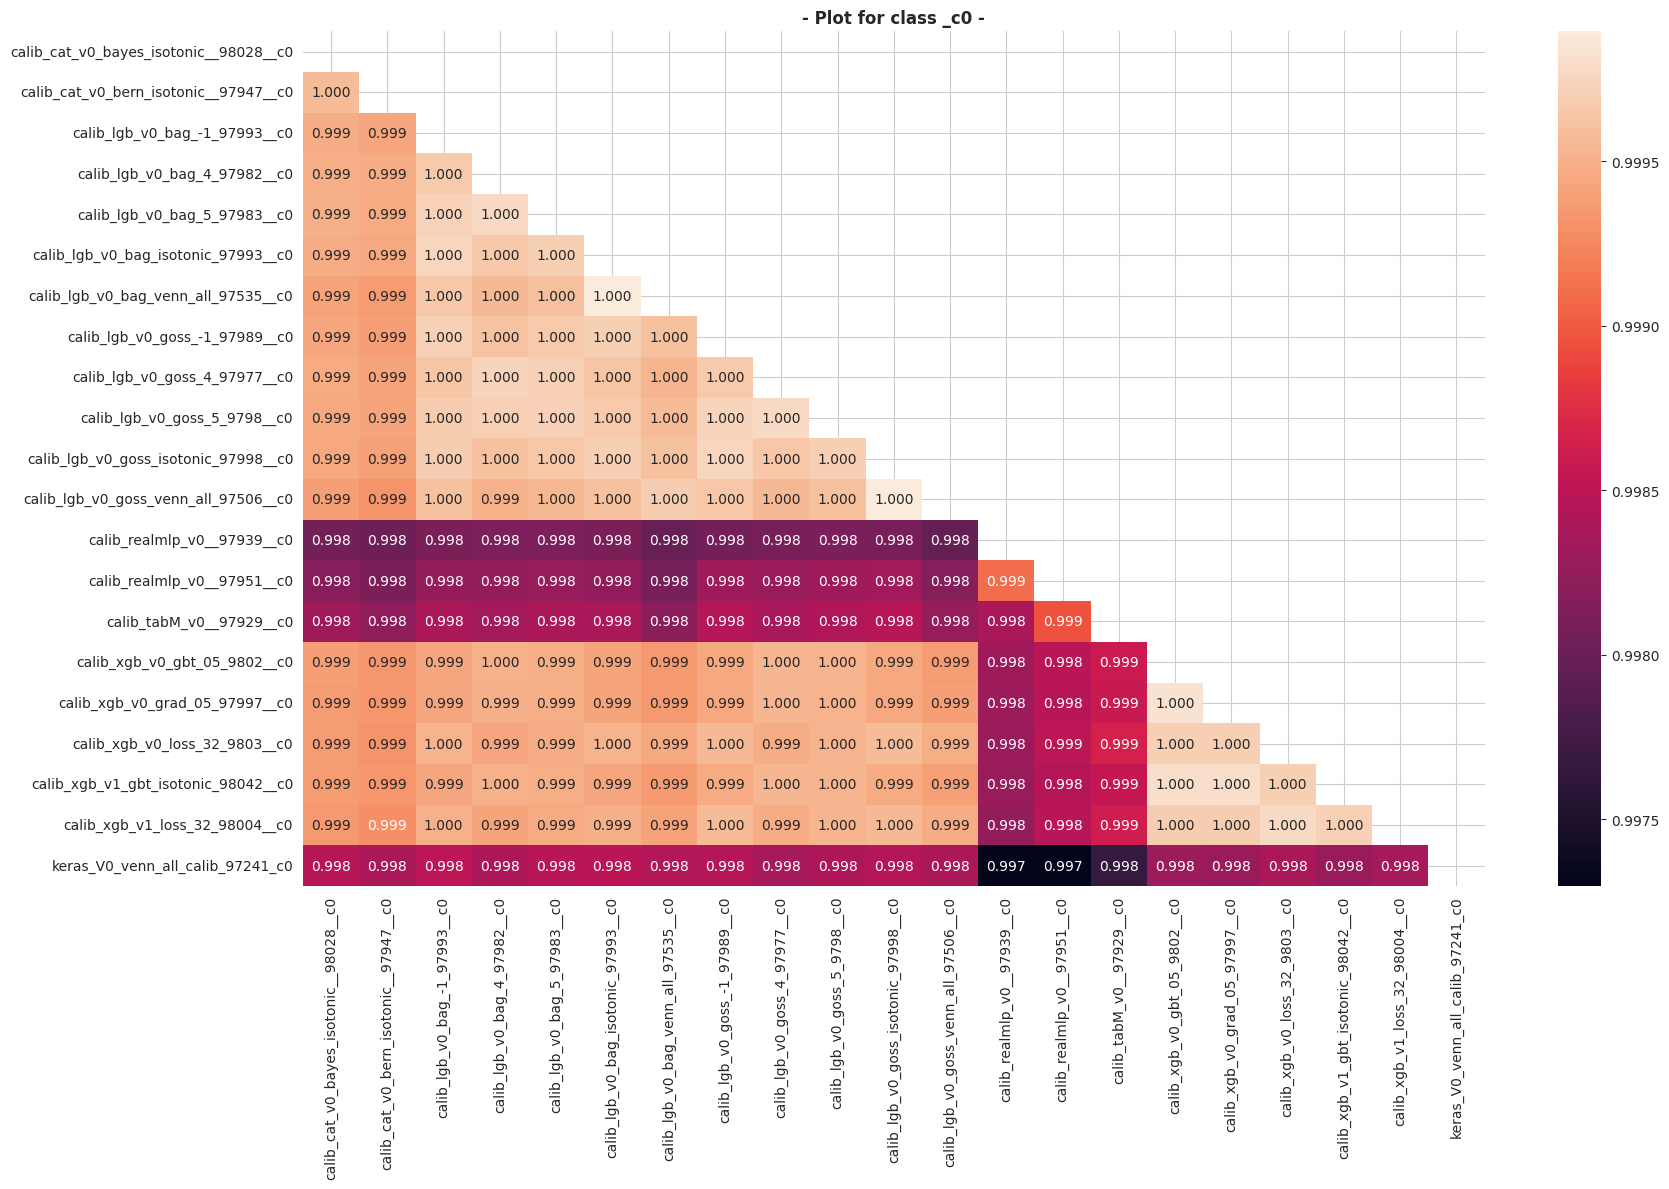

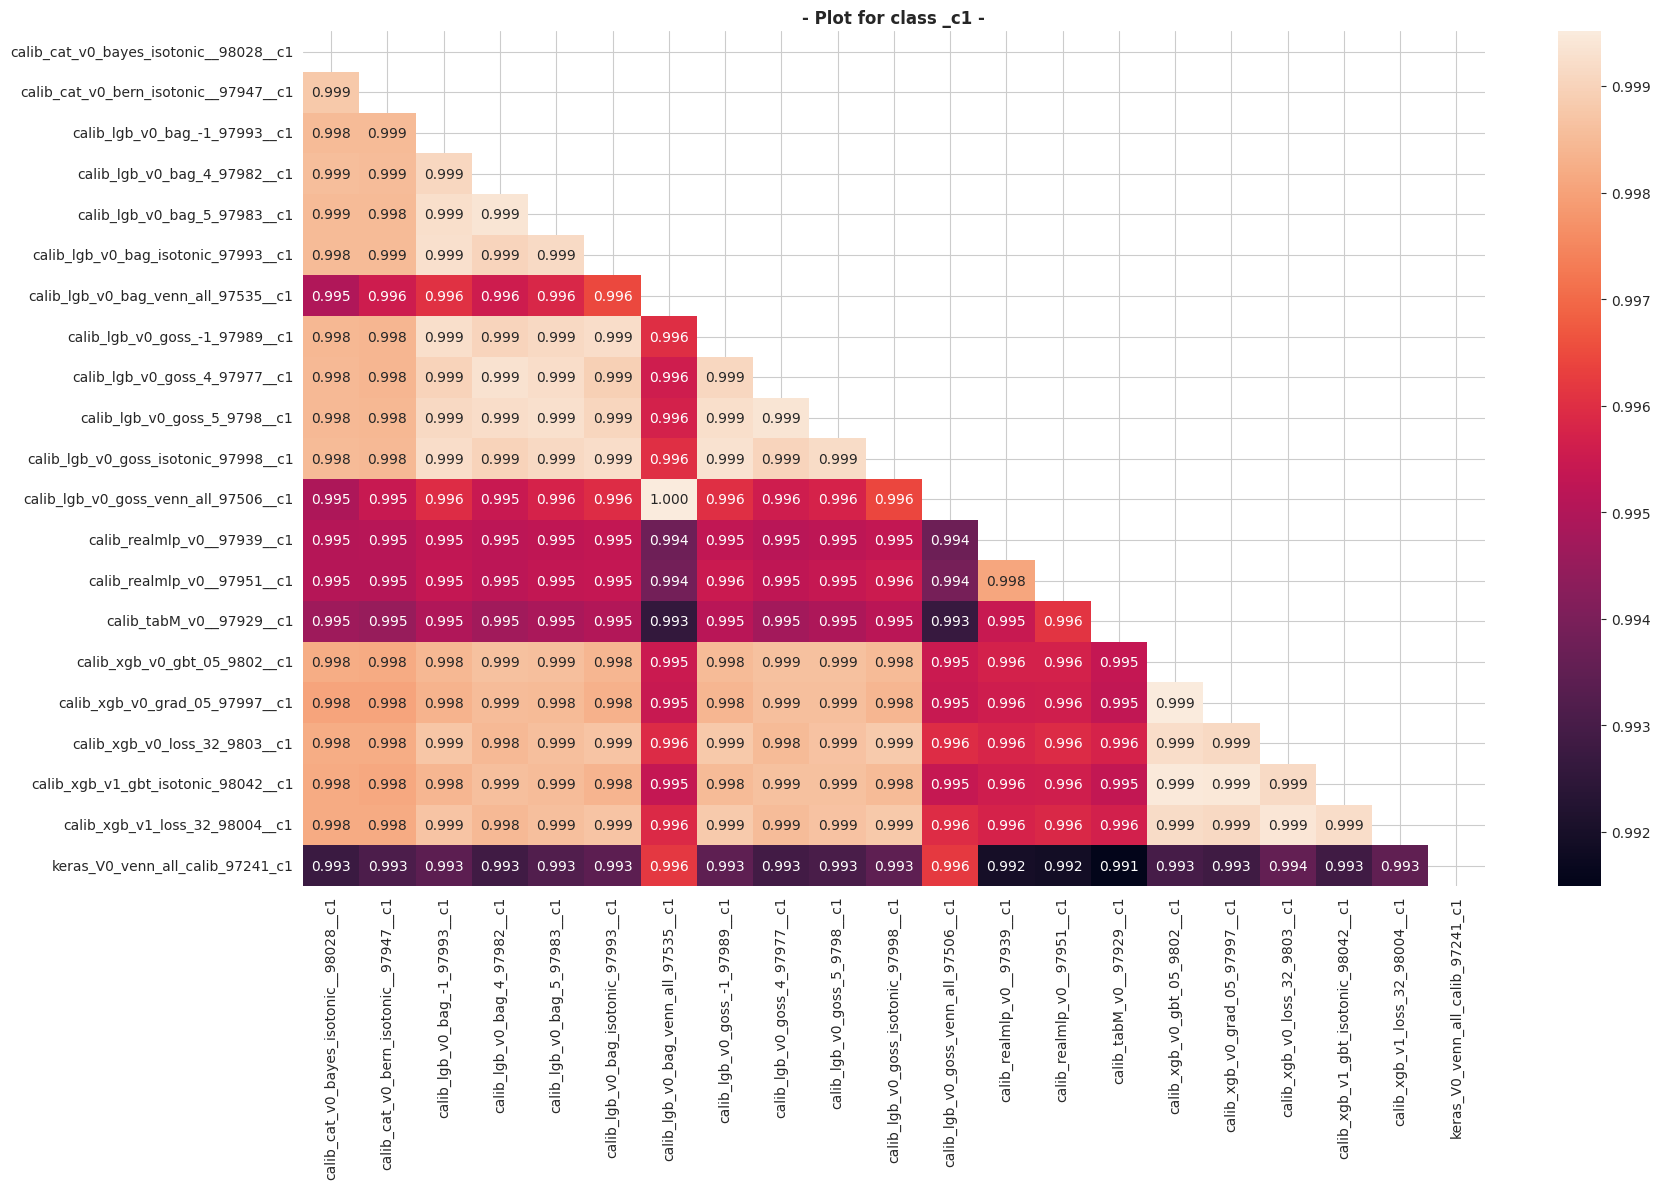

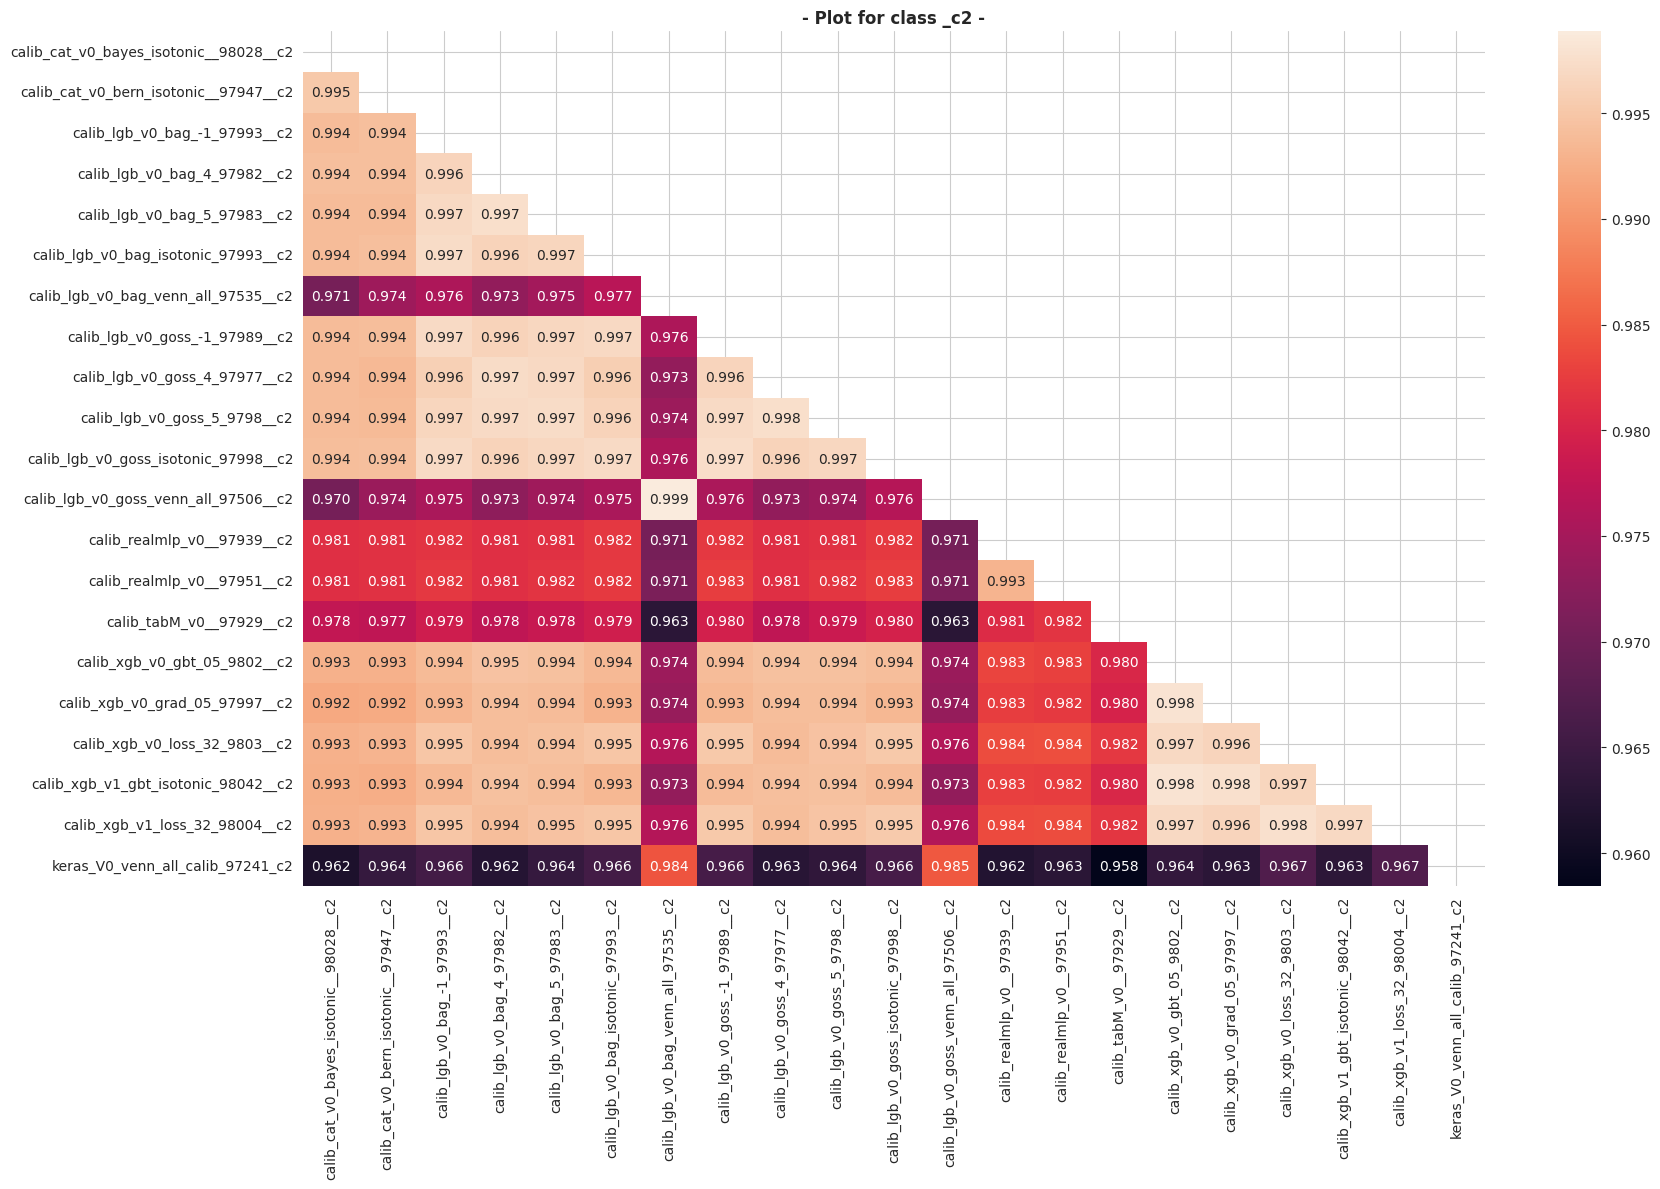

In [9]:
## -- Correlation Analysis --
classes_ = ['_c0', '_c1', '_c2']

for i, class_ in enumerate(classes_):
    cls_ = [c for c in oof_df.columns if c.endswith(class_)]
    corr_df = oof_df[cls_].corr()

    plt.figure(figsize=(18, 12))
    sns.heatmap(corr_df, mask=np.triu(corr_df), annot=True, fmt='.3f')
    plt.title(f'- Plot for class {class_} -', fontweight='semibold')
    plt.tight_layout()
    plt.show()
    print()

In [10]:
from sklearn.inspection import permutation_importance

def plot_permutation_importance(model, X, y, categories=None):
    if categories is not None:
        for c in categories:
            X[c] = X[c].factorize()[0]
            X[c] = X[c].astype('category')
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
    
    ## -- Compute Model Importances --
    print(' • Training base model... ', end='')
    model.fit(X_train, y_train, sample_weight=get_weights(y_train, y))
    model_importances = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)
    print('Complete!')

    ## -- Compute Permutation Importances --
    print(' • Training permutation... ', end='')
    result = permutation_importance(
        model, X_test, y_test,
        n_repeats=5, #max_samples=0.5,
        sample_weight=get_weights(y_test, y),
        scoring='balanced_accuracy',
        random_state=42, n_jobs=-1
    )
    perm_sorted_idx = result.importances_mean.argsort()
    print('Complete!')

    fig, axs = plt.subplots(1, 2, figsize=(18, len(perm_sorted_idx)*0.25))
    
    sns.barplot(model_importances, orient='h', palette='RdYlGn_r', ax=axs[0])
    # model_importances.sort_values().plot.barh(ax=axs[0], palette='RdYlGn')
    axs[0].set_xlabel("Model importance")
    
    axs[1].boxplot(result.importances[perm_sorted_idx].T, orientation='horizontal',
                    tick_labels=X.columns[perm_sorted_idx], whis=(0, 100))
    axs[1].axvline(x=0, color="k", linestyle="--")
    axs[1].set_xlabel("Permutaion importance")

    fig.suptitle("Logistic (coefs) vs. Permutation (scores) on validation data", y=1.0)
    _ = fig.tight_layout()

print('Permutation Importance function ready!')

Permutation Importance function ready!


 • Training base model... Complete!
 • Training permutation... Complete!
CPU times: user 3.45 s, sys: 426 ms, total: 3.87 s
Wall time: 29 s


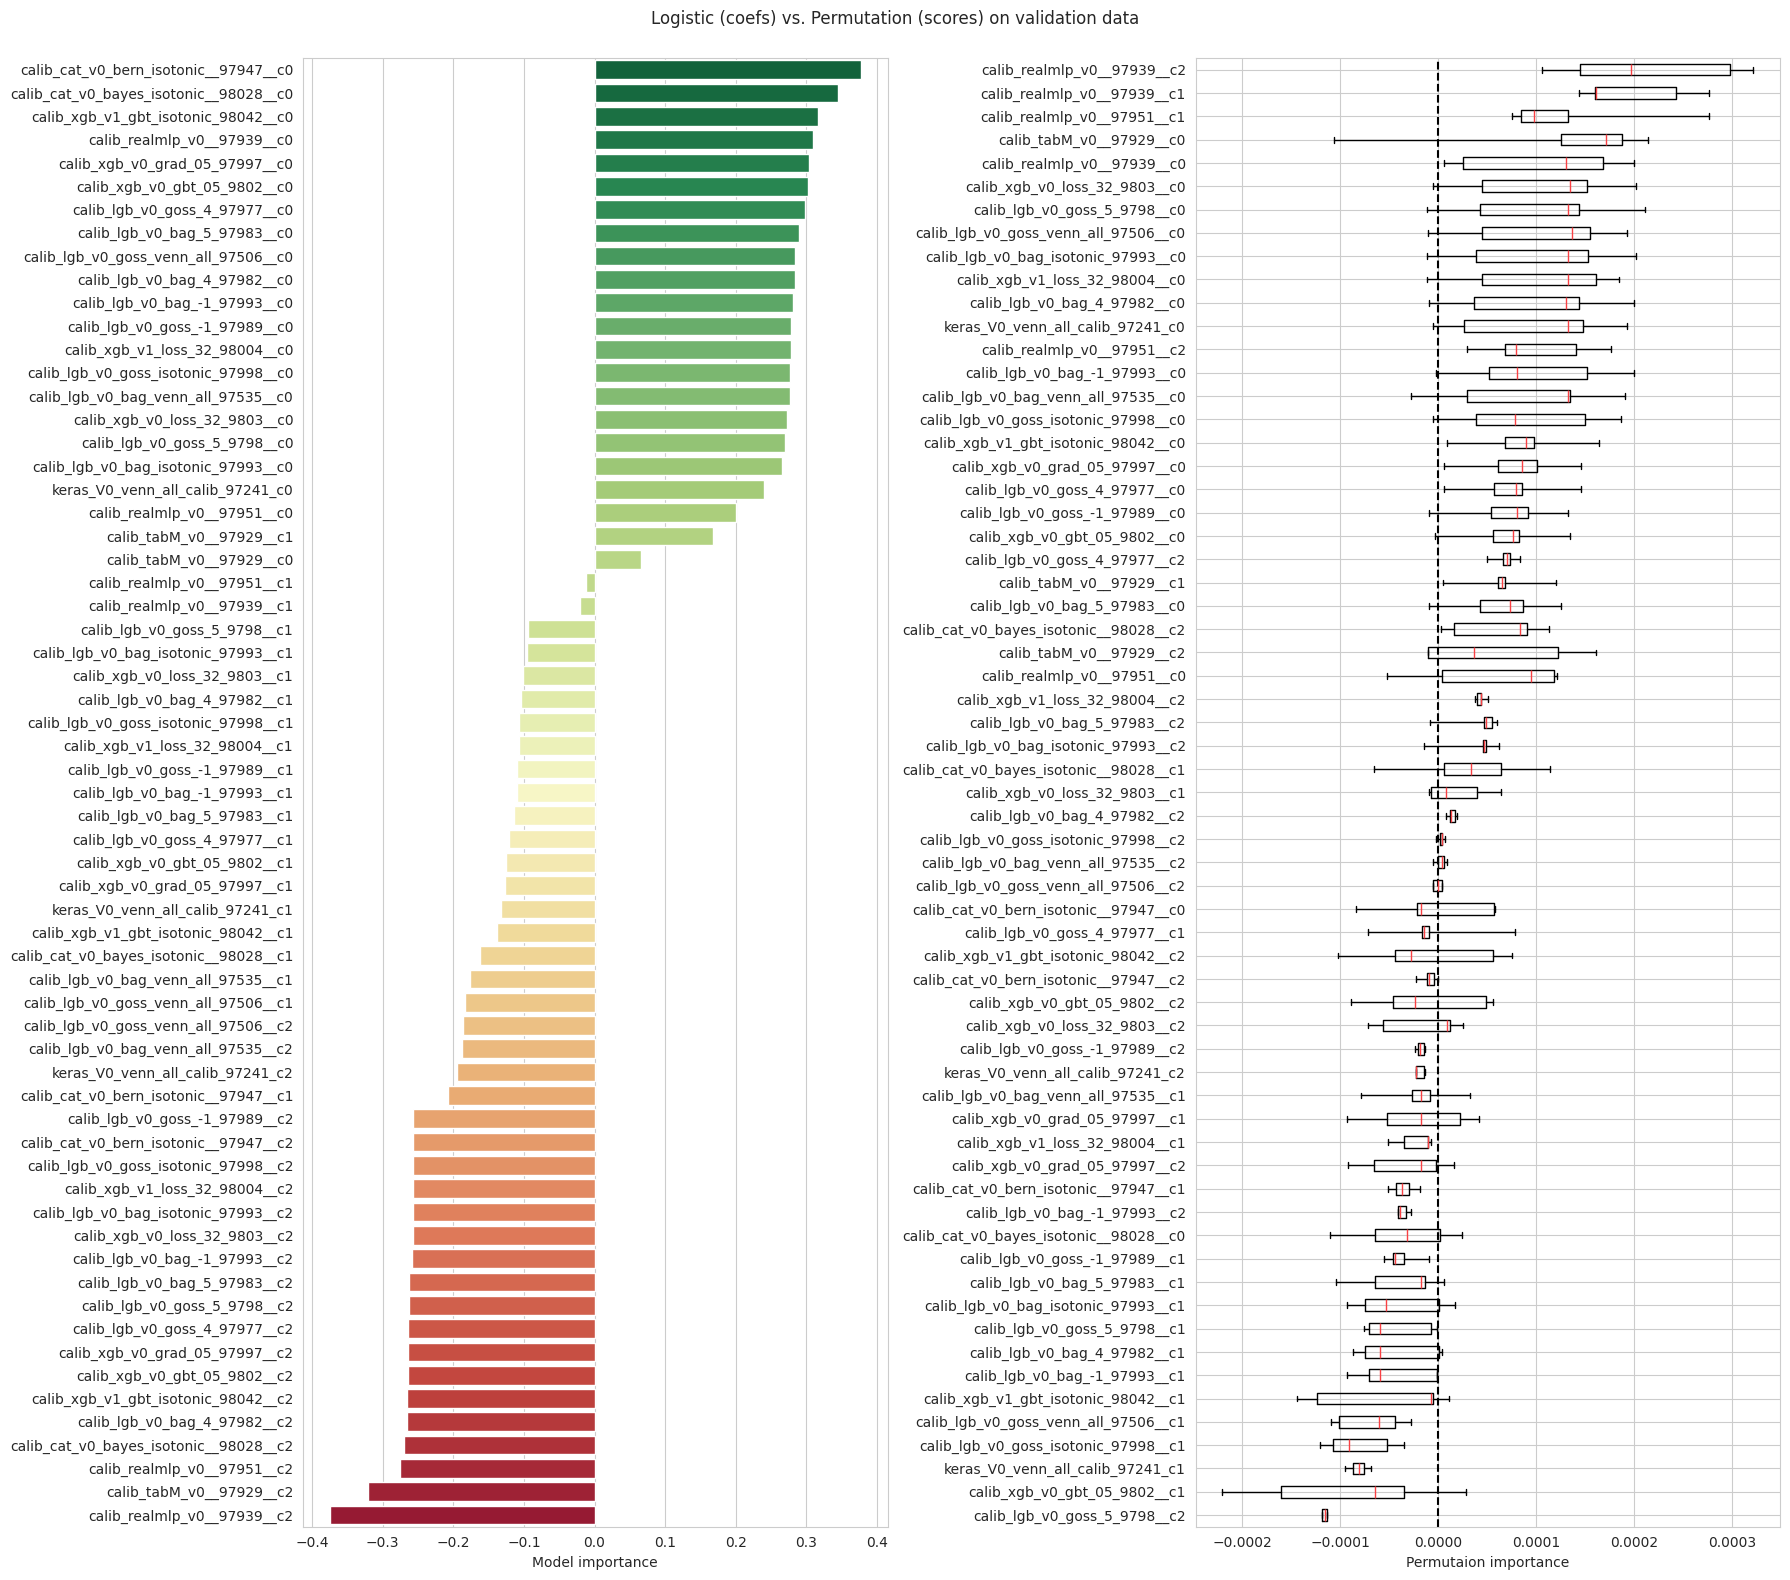

In [11]:
%%time

PARAMS = dict(
    max_iter=10_000, cv=5, tol=1e-4,
    multi_class='multinomial',
    scoring='neg_log_loss',
    # solver='saga', penalty='l2',
    n_jobs=-1, random_state=CFG.SEED,
)

model = LogisticRegressionCV(**PARAMS)

plot_permutation_importance(model, oof_df, y_true)

## ENSEMBLE 1: STACKING

In [12]:
def train_meta(model_clf, oof_df, pred_df, features, y_true, 
               kf_splits=10, rank_first=False, verbose=True):

    kf = StratifiedKFold(n_splits=kf_splits, shuffle=True, random_state=CFG.SEED)

    oof_preds  = np.zeros((oof_df.shape[0], 3))
    test_preds = np.zeros((pred_df.shape[0], 3))
    num_classes = len(np.unique(y_true))
    X = oof_df[features]

    val_scores = []
    oof_alphas = []

    if model_clf == 'log':
        print(f"### {kf_splits} Folds | Logistic | {X.shape} ###")
    elif model_clf == 'cat':
        print(f"### {kf_splits} Folds | Catboost | {X.shape} ###")

    for fold, (trn_idx, val_idx) in enumerate(kf.split(X, y_true)):

        X_trn, y_trn = X.iloc[trn_idx], y_true[trn_idx]
        X_val, y_val = X.iloc[val_idx], y_true[val_idx]

        X_test = pred_df[features].copy()

        if model_clf == 'log':
            model = LogisticRegressionCV(
                max_iter=10_000, tol=1e-4, cv=5,
                multi_class='multinomial', scoring='neg_log_loss',
                n_jobs=-1, random_state=CFG.SEED,
                # class_weight = get_weights(y_trn, y_trn),
            )
            if rank_first:
                for col in features:
                    X_trn[col] = scipy.stats.rankdata(X_trn[col].to_numpy())
                    pred_df[col] = scipy.stats.rankdata(pred_df[col].to_numpy())

                    scaler = StandardScaler()
                    X_trn[col] = scaler.fit_transform(X_trn[[col]], y_true)
                    pred_df[col] = scaler.transform(X_test[[col]])

            model.fit(X_trn, y_trn, sample_weight=get_weights(y_trn, y_trn))
            oof_preds[val_idx] = model.predict_proba(X_val)
            test_preds += model.predict_proba(X_test[features])
            val_scores.append(balanced_acc(y_val, oof_preds[val_idx]))
            if verbose:
                print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.6f} | ", end='')
                print(f"Best 'C': {model.C_[0]:.4f}")
            oof_alphas.append(model.C_[0])
        elif model_clf == 'cat':
            PARAMS = {
                'loss_function': 'MultiClass',
                'eval_metric': 'MultiClass',
                'classes_count': num_classes,
                'depth': 4,
                # 'cat_features': CATS,
                # 'l2_leaf_reg': 1.0,
                'random_state': CFG.SEED,
                'verbose': False,
                'allow_writing_files': False,
                'thread_count': -1,
                'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
            }
            model = cgb.CatBoostClassifier(**PARAMS)
            model.fit(X_trn, y_trn, sample_weight=get_weights(y_trn, y_trn))
            oof_preds[val_idx] = model.predict_proba(X_val)
            test_preds += model.predict_proba(X_test[features])
            val_scores.append(balanced_acc(y_val, oof_preds[val_idx]))
            if verbose:
                print(f"Fold {fold+1}/{kf.n_splits}: {val_scores[-1:][0]:.6f}")

    test_preds /= kf.n_splits

    final_score = np.round(balanced_acc(y_true, oof_preds), 7)
    print('-'*40)
    print(f"✔ Stack score: {final_score} | Models: {len(features)}")
    print("-"*40)

    return test_preds, oof_preds, final_score

print('Stacker function ready!')

Stacker function ready!


## LOGISTIC

In [13]:
%%time

test_log, oof_log, log_score = train_meta(
    model_clf='log',
    oof_df=oof_df,
    pred_df=pred_df,
    features=oof_df.columns,
    y_true=y_true,
    # rank_first=True,
    # kf_splits=5,
)
print()
print(oof_log.shape, test_log.shape)

### 10 Folds | Logistic | (630000, 63) ###
Fold 1/10: 0.981000 | Best 'C': 0.0464
Fold 2/10: 0.979489 | Best 'C': 0.0464
Fold 3/10: 0.980977 | Best 'C': 0.0464
Fold 4/10: 0.980538 | Best 'C': 166.8101
Fold 5/10: 0.981891 | Best 'C': 0.0464
Fold 6/10: 0.982124 | Best 'C': 0.3594
Fold 7/10: 0.983066 | Best 'C': 0.0464
Fold 8/10: 0.979935 | Best 'C': 0.0464
Fold 9/10: 0.979712 | Best 'C': 0.0464
Fold 10/10: 0.982554 | Best 'C': 0.3594
----------------------------------------
✔ Stack score: 0.9811286 | Models: 63
----------------------------------------

(630000, 3) (270000, 3)
CPU times: user 16.4 s, sys: 2.63 s, total: 19 s
Wall time: 3min 44s


In [14]:
# %%time

# test_cat, oof_cat, cat_score = train_meta(
#     model_clf='cat',
#     oof_df=oof_df,
#     pred_df=pred_df,
#     features= oof_df.columns,
#     y_true=y_true,
#     # rank_first=True,
#     # kf_splits=5,
# )
# print()
# print(oof_cat.shape, test_cat.shape)

In [15]:
# %%time
# ## -- Perform sequential feature selection --
# # oof_df.iloc[:3, np.r_[0:9, 18:21, 24:27]].columns

# test_log, oof_log, log_score = train_meta(
#     model_clf='log',
#     oof_df=oof_df,
#     pred_df=pred_df,
#     features=oof_df.iloc[:2, np.r_[0:9, 12:15, 30:39, 42:51, 60:63]].columns,
#     y_true=y_true,
#     # rank_first=True,
#     # kf_splits=5,
# )

# print()
# print(oof_log.shape, test_log.shape)

# # ----------------------------------------
# # ✔ Stack score: 0.9811991 | Models: 33
# # ----------------------------------------

In [16]:
%%time

## -- Get model scores --
model_scores = {}

for i, model_names in enumerate(per_model_class_output):
    n = model_names[0].replace('__c0', '')
    n = n.replace('_c0', '')
    print(f"\n {CFG.YELLOW}• Model {i+1}/{len(per_model_class_output)}: {n}{CFG.RESET}")
    _, __, score = train_meta(
        model_clf='log',
        oof_df=oof_df,
        pred_df=pred_df,
        features=model_names,
        y_true=y_true,
        verbose=False,
    )
    model_scores[n] = score


 • Model 1/21: calib_cat_v0_bayes_isotonic__98028
### 10 Folds | Logistic | (630000, 3) ###
----------------------------------------
✔ Stack score: 0.9802609 | Models: 3
----------------------------------------

 • Model 2/21: calib_cat_v0_bern_isotonic__97947
### 10 Folds | Logistic | (630000, 3) ###
----------------------------------------
✔ Stack score: 0.9797457 | Models: 3
----------------------------------------

 • Model 3/21: calib_lgb_v0_bag_-1_97993
### 10 Folds | Logistic | (630000, 3) ###
----------------------------------------
✔ Stack score: 0.980054 | Models: 3
----------------------------------------

 • Model 4/21: calib_lgb_v0_bag_4_97982
### 10 Folds | Logistic | (630000, 3) ###
----------------------------------------
✔ Stack score: 0.9800718 | Models: 3
----------------------------------------

 • Model 5/21: calib_lgb_v0_bag_5_97983
### 10 Folds | Logistic | (630000, 3) ###
----------------------------------------
✔ Stack score: 0.9802169 | Models: 3
------------

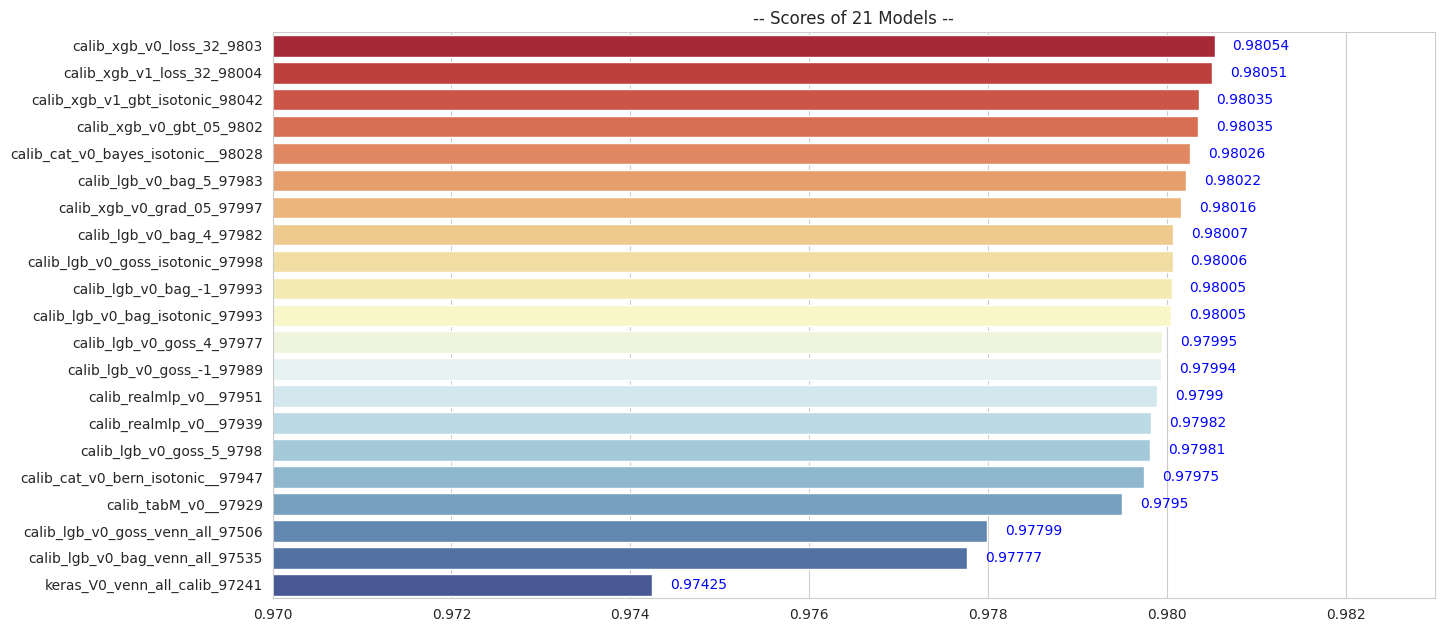

In [17]:
## -- Plot model scores --
model_scores_df = pd.Series(model_scores).sort_values(ascending=False)

plt.figure(figsize=(15, len(model_scores)*0.35))
sns.barplot(model_scores_df, orient='h', palette='RdYlBu', native_scale=True)

for i, score in enumerate(model_scores_df.values):
    plt.text(score+2e-4, model_scores_df.index[i], np.round(score, 5), ha='left', va='center', color='b')

plt.title(f'-- Scores of {len(model_scores_df)} Models --')
plt.xlim(.97, .983)
# plt.tight_layout()
plt.show()

In [18]:
# list_c = [col for idx in model_scores_df.index[1:] for col in oof_df.columns if idx in col]
# list_c = [word for word in oof_df.columns if any(sub in word for sub in model_scores_df.index[:1].tolist())]

rng = np.random.default_rng()
selected = rng.choice(per_model_class_output, 1, replace=False) #[0]
print(selected)
print()
# print(rng.permutation(selected))

## -- Flatten a list of lists --
flat_list = [item for sublist in selected for item in sublist]
print(rng.permutation(flat_list))

[['calib_lgb_v0_goss_4_97977__c0' 'calib_lgb_v0_goss_4_97977__c1'
  'calib_lgb_v0_goss_4_97977__c2']]

['calib_lgb_v0_goss_4_97977__c2' 'calib_lgb_v0_goss_4_97977__c1'
 'calib_lgb_v0_goss_4_97977__c0']


In [19]:
list_a = [c for c in range(len(per_model_class_output))]
print(f"Original list: {list_a:}")

# selected = rng.choice(list_a, 1, replace=False)
# selected 
pop_item = list_a.pop(int(rng.choice(list_a, 1, replace=False)))
print(f"Popped item: {pop_item}")
print(f"Updated list: {list_a}")

list_a_perm = rng.permutation(list_a)
print(f"Shuffle list: {list_a_perm}")

Original list: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Popped item: 8
Updated list: [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Shuffle list: [14  4 18 19  0  3  6  1 12 13 15  7  5 10 17 16 11  9 20  2]


In [20]:
# all_scores = {}
# all_models = {}

# for i in tqdm(range(len(per_model_class_output))):
#     best_score   = 0
#     best_models  = []

#     all_models   = per_model_class_output.copy()
#     models_id    = [_ for _ in range(len(per_model_class_output))]
#     init_model   = all_models[i]
#     # result = [data[i] for i in indices]   # ['a', 'b', 'c', 'd', 'e', 'f']
#     # print(f"\n • Starting with {init_model} ...")
#     _id = models_id.pop(i)
#     other_models = [all_models[_] for _ in models_id] # all_models[models_id]
#     other_models = rng.permutation(other_models).tolist()
    
#     print(f"\n{i+1}/{len(model_scores)} • Starting with {init_model[0]} *****")

#     for j, m in tqdm(enumerate(other_models)):
#         total_models = init_model + m + best_models

#         print(f"\t{j+1}/{len(model_scores)-(j+1)} • Added {m[0]} *****")
#         print('-'*70)
#         _, __, _score = train_meta(
#             model_clf='log',
#             oof_df=oof_df,
#             pred_df=pred_df,
#             y_true=y_true,
#             features=total_models, 
#             verbose=False,
#         )

#         if _score > best_score:
#             print(f"{CFG.GREEN} • {m[0]} -> Score improved: {_score}{CFG.RESET}")
#             best_score = _score
#             best_models.extend(m)
#         else:
#             print(f"{CFG.YELLOW} • {m[0]} -> Score depreciate: {_score}{CFG.RESET}")

#         print()
    
#     print(f"\nBest score: {best_score:.5f}")
#     print(f"Best models: {len(best_models)//num_classes}\n{best_models}\n")

#     all_scores[i]  = best_score
#     best_models[i] = best_models.append(init_model)


In [21]:
# Best score: 0.98129
# Best models: 11
top_models = [
    'calib_cat_v0_bayes_isotonic__98028__c0',
    'calib_cat_v0_bayes_isotonic__98028__c1',
    'calib_cat_v0_bayes_isotonic__98028__c2',
    ## ---------------------------------------
    'calib_lgb_v0_goss_venn_all_97506__c0', 'calib_lgb_v0_goss_venn_all_97506__c1',
    'calib_lgb_v0_goss_venn_all_97506__c2', 'calib_lgb_v0_bag_venn_all_97535__c0',
    'calib_lgb_v0_bag_venn_all_97535__c1', 'calib_lgb_v0_bag_venn_all_97535__c2',
    'calib_xgb_v0_gbt_05_9802__c0', 'calib_xgb_v0_gbt_05_9802__c1', 'calib_xgb_v0_gbt_05_9802__c2',
    'calib_xgb_v1_gbt_isotonic_98042__c0', 'calib_xgb_v1_gbt_isotonic_98042__c1',
    'calib_xgb_v1_gbt_isotonic_98042__c2', 'calib_xgb_v0_loss_32_9803__c0',
    'calib_xgb_v0_loss_32_9803__c1', 'calib_xgb_v0_loss_32_9803__c2', 'calib_realmlp_v0__97939__c0',
    'calib_realmlp_v0__97939__c1', 'calib_realmlp_v0__97939__c2', 'calib_realmlp_v0__97951__c0',
    'calib_realmlp_v0__97951__c1', 'calib_realmlp_v0__97951__c2', 'calib_lgb_v0_bag_-1_97993__c0',
    'calib_lgb_v0_bag_-1_97993__c1', 'calib_lgb_v0_bag_-1_97993__c2',
    'calib_lgb_v0_goss_isotonic_97998__c0', 'calib_lgb_v0_goss_isotonic_97998__c1',
    'calib_lgb_v0_goss_isotonic_97998__c2', 'calib_lgb_v0_goss_-1_97989__c0',
    'calib_lgb_v0_goss_-1_97989__c1', 'calib_lgb_v0_goss_-1_97989__c2',
    'keras_V0_venn_all_calib_97241_c0', 'keras_V0_venn_all_calib_97241_c1',
    'keras_V0_venn_all_calib_97241_c2'
]

In [22]:
%%time

## -- Train with top models --
print(f"Selected features: {top_models}\n")

test_log, oof_log, log_score = train_meta(
    model_clf='log',
    oof_df=oof_df,
    pred_df=pred_df,
    features=top_models,
    y_true=y_true,
)

print()
print(oof_log.shape, test_log.shape)

Selected features: ['calib_cat_v0_bayes_isotonic__98028__c0', 'calib_cat_v0_bayes_isotonic__98028__c1', 'calib_cat_v0_bayes_isotonic__98028__c2', 'calib_lgb_v0_goss_venn_all_97506__c0', 'calib_lgb_v0_goss_venn_all_97506__c1', 'calib_lgb_v0_goss_venn_all_97506__c2', 'calib_lgb_v0_bag_venn_all_97535__c0', 'calib_lgb_v0_bag_venn_all_97535__c1', 'calib_lgb_v0_bag_venn_all_97535__c2', 'calib_xgb_v0_gbt_05_9802__c0', 'calib_xgb_v0_gbt_05_9802__c1', 'calib_xgb_v0_gbt_05_9802__c2', 'calib_xgb_v1_gbt_isotonic_98042__c0', 'calib_xgb_v1_gbt_isotonic_98042__c1', 'calib_xgb_v1_gbt_isotonic_98042__c2', 'calib_xgb_v0_loss_32_9803__c0', 'calib_xgb_v0_loss_32_9803__c1', 'calib_xgb_v0_loss_32_9803__c2', 'calib_realmlp_v0__97939__c0', 'calib_realmlp_v0__97939__c1', 'calib_realmlp_v0__97939__c2', 'calib_realmlp_v0__97951__c0', 'calib_realmlp_v0__97951__c1', 'calib_realmlp_v0__97951__c2', 'calib_lgb_v0_bag_-1_97993__c0', 'calib_lgb_v0_bag_-1_97993__c1', 'calib_lgb_v0_bag_-1_97993__c2', 'calib_lgb_v0_goss_i

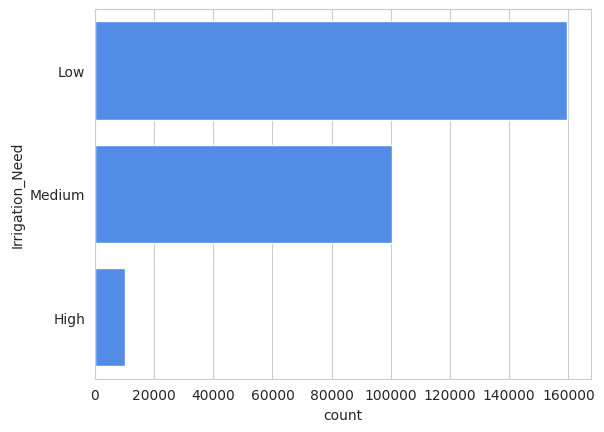

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,Medium
9,630009,Low


In [23]:
## -- Submission --
# np.save(f"oof_log_cvStack_{str(log_score).split('.')[1]}.npy", oof_log)
# np.save(f"test_log_cvStack_{str(log_score).split('.')[1]}.npy", test_log)

submit[TARGET] = pd.Series(np.argmax(test_log, axis=1)).map(mapping_r)
submit.to_csv(f"submit_log_stack_{str(log_score).split('.')[1]}.csv", index=False)

sns.countplot(submit[TARGET])
plt.show()

submit.head(10)

In [24]:
%%time

## -- Train on full data --
log_clf = LogisticRegressionCV(
    max_iter=10_000, tol=1e-4,
    random_state=CFG.SEED, cv=5,
    scoring='neg_log_loss',
    n_jobs=-1, #verbose=1,
)

log_clf.fit(
    oof_df[top_models],
    y_true,
    sample_weight=get_weights(y_true, y_true)
)
full_preds = log_clf.predict_proba(pred_df[top_models])

## -- Submission --
n = f"submit_log_stackFULL_{str(log_score).split('.')[1]}.csv"
submit[TARGET] = pd.Series(np.argmax(full_preds, axis=1)).map(mapping_r)
submit.to_csv(n, index=False)
print('LOGISTIC Submission File Exported -> ', n)

submit.head(10)

LOGISTIC Submission File Exported ->  submit_log_stackFULL_9812868.csv
CPU times: user 1.56 s, sys: 177 ms, total: 1.74 s
Wall time: 14.8 s


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,Medium
9,630009,Low


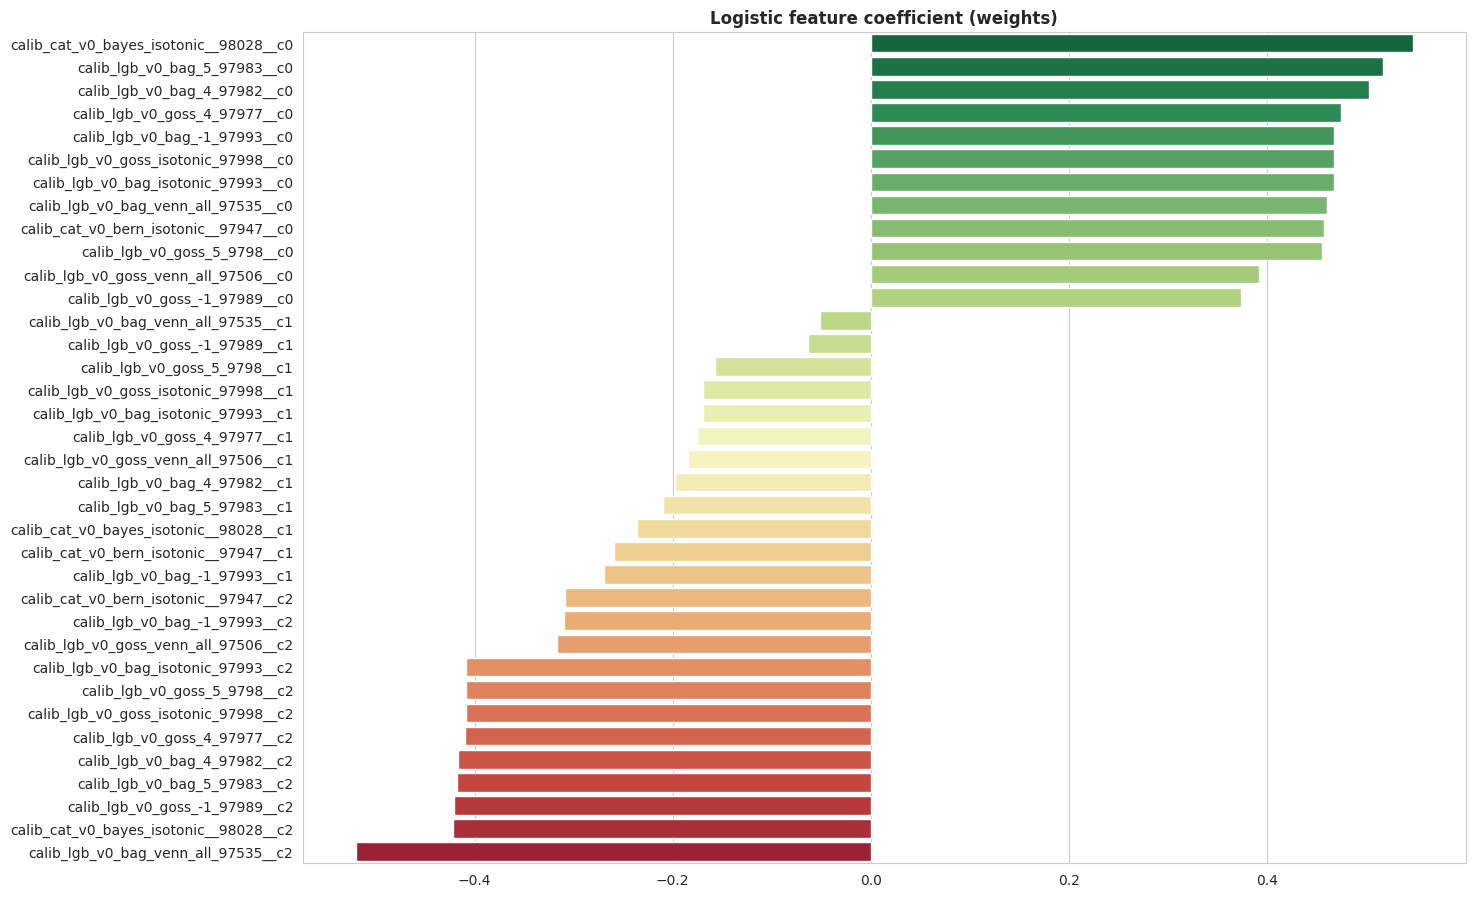

In [25]:
## -- PLOT FEATURE COEFs --
log_table = pd.Series(dict(zip(oof_df.columns, log_clf.coef_[0]))).sort_values(ascending=False)

plt.figure(figsize=(15, len(log_table)*0.3))
sns.barplot(log_table, orient='h', palette='RdYlGn_r')
plt.title('Logistic feature coefficient (weights)', fontweight='semibold')

# plt.tight_layout()
plt.savefig('log_oof_coef')
plt.show()

In [26]:
log_features = log_table[log_table.values > 0].index.tolist()
print('Top features by Logistic:', len(log_features))

Top features by Logistic: 12


## ENSEMBLE: CLASS WEIGHT WITH OPTUNA

In [27]:
try:
    import optuna
except:
    %pip install -q optuna
    import optuna

def objective(trial):
    ## -- Random search class weights --
    cw0 = trial.suggest_float('cw0', 0.5, 3.0)  # Class weight 0
    cw1 = trial.suggest_float('cw1', 0.5, 3.0)  # Class weight 1
    cw2 = trial.suggest_float('cw2', 0.5, 3.0)  # Class weight 2
    
    ## Apply class weights
    class_weights = np.array([cw0, cw1, cw2])
    adjusted_probs = oof_log * class_weights
    
    ## -- Get adjusted probabilities --
    adjusted_probs = adjusted_probs / adjusted_probs.sum(axis=1, keepdims=True)
    
    ## -- Compute metric --
    acc = balanced_acc(y_true, adjusted_probs)
    return acc

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=1313),
    study_name='class_weight_optimization'
)

## -- Start Search --
study.optimize(objective, n_trials=300, show_progress_bar=True)

[I 2026-05-02 11:05:04,867] A new study created in memory with name: class_weight_optimization


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2026-05-02 11:05:04,922] Trial 0 finished with value: 0.9799201483029037 and parameters: {'cw0': 2.9812560365972574, 'cw1': 0.5775328156746263, 'cw2': 2.627274788429955}. Best is trial 0 with value: 0.9799201483029037.
[I 2026-05-02 11:05:04,966] Trial 1 finished with value: 0.9809651898493637 and parameters: {'cw0': 2.9572203878565406, 'cw1': 1.0095877206270099, 'cw2': 1.7435346215947873}. Best is trial 1 with value: 0.9809651898493637.
[I 2026-05-02 11:05:05,011] Trial 2 finished with value: 0.9810192328982984 and parameters: {'cw0': 1.1943518973761866, 'cw1': 2.713658733436075, 'cw2': 2.137823821220442}. Best is trial 2 with value: 0.9810192328982984.
[I 2026-05-02 11:05:05,058] Trial 3 finished with value: 0.98043024048643 and parameters: {'cw0': 2.5774521387440577, 'cw1': 0.6519670223939715, 'cw2': 1.9750642031598191}. Best is trial 2 with value: 0.9810192328982984.
[I 2026-05-02 11:05:05,102] Trial 4 finished with value: 0.9807829639380058 and parameters: {'cw0': 2.88545367439

In [28]:
best_score = np.round(study.best_value, 5)

print(f"\n{CFG.GREEN} • Optua Best Score: {best_score}{CFG.RESET}")
print("\nClass Weights:")
print(f"  class_0 = {study.best_params['cw0']:.4f}")
print(f"  class_1 = {study.best_params['cw1']:.4f}")
print(f"  class_2 = {study.best_params['cw2']:.4f}")

## Get best weight per class --
best_cw = np.array([study.best_params['cw0'], 
                    study.best_params['cw1'], 
                    study.best_params['cw2']])

## -- Apply best weights to test predictions --
final_test_probs = test_log * best_cw
final_test_probs = final_test_probs / final_test_probs.sum(axis=1, keepdims=True)

## -- Get final labels --
final_test_preds = np.argmax(final_test_probs, axis=1)

## -- Save submission file --
file_name = f"submit_Optimized_Weights_Optuna_{str(best_score).split('.')[1]}.csv"

submit[TARGET] = pd.Series(final_test_preds).map(mapping_r)
submit.to_csv(file_name, index=False)
submit.head(10)


 • Optua Best Score: 0.98136

Class Weights:
  class_0 = 1.8266
  class_1 = 2.9562
  class_2 = 2.9237


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,Medium
9,630009,Low


In [29]:
# !rm -r /kaggle/working